# Fine-tuning — GPD

Fine-tunes GPD using the shared local dataset and saves the trained weights and loss history. Architecture-specific settings are defined below.


## Key settings

GPD classifies the center of a 4 s window as P, S, or noise. Fine-tuning uses point labels and cross-entropy, with dev loss guiding early stopping. Inference later scans windows across a longer trace.

## 1. Environment + shared utilities

In [1]:
import sys
sys.path.insert(0, r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion\src\training")
import training_utils as tu
import torch
import numpy as np
import seisbench.models as sbm
import seisbench.generate as sbg
from torch.utils.data import DataLoader
tu.banner()

seisbench 0.12.3 | torch 2.5.1+cu121 | device: cuda


## 2. Configuration

In [2]:
ARCH       = "GPD"
STATIONS   = None
PRETRAINED = "instance"
EPOCHS     = 100
BATCH_SIZE = 128
LR         = 1e-4
SIGMA      = 20
SEED       = 42
PATIENCE   = 6
MIN_DELTA  = 1e-4
IN_SAMPLES = 400

torch.manual_seed(SEED); np.random.seed(SEED)
FT_CKPT   = tu.MODELS_DIR / f"{ARCH.lower()}_ft.pt"
BASE_CKPT = tu.MODELS_DIR / f"{ARCH.lower()}_baseline_{PRETRAINED}.pt"
print("Stations:", "ALL" if not STATIONS else STATIONS, "| checkpoint:", FT_CKPT.name)

Stations: ALL | checkpoint: gpd_ft.pt


## 3. Dataset (train / dev)

In [3]:
data = tu.load_dataset(STATIONS)
train, dev, test = data.train_dev_test()
print()
tu.split_summary(train, "train"); tu.split_summary(dev, "dev")
print(f"  (test reserved for evaluate: {len(test)})")

No filter (all stations): 106580 traces
stations: ['BRJC', 'CBOC', 'CHI', 'DBB', 'GUY2C', 'JAMC', 'MAL', 'NOR', 'ORTC', 'PAL', 'PIZC', 'PRA', 'PTB', 'PTGC', 'QUBC', 'RUS', 'SPBC', 'TAM', 'URE', 'URMC', 'YOT', 'ZAR']

  train: 74600  {'earthquake': 37300, 'noise': 37300}
  dev  : 16414  {'earthquake': 8207, 'noise': 8207}
  (test reserved for evaluate: 15566)


## 4. Base model + baseline snapshot

In [4]:
model = sbm.GPD.from_pretrained(PRETRAINED).to(tu.DEVICE)
print("labels:", model.labels, "| in_samples:", model.in_samples)
torch.save(model.state_dict(), BASE_CKPT)
print("baseline saved:", BASE_CKPT.name)

c:\Users\moise\miniconda3\envs\tesismaster\Lib\site-packages\seisbench\models\base.py:952: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_p

labels: PSN | in_samples: 400
baseline saved: gpd_baseline_instance.pt


## 5. Classification generator (GPD-specific)

In [5]:
def make_gen(subset):
    gen = sbg.GenericGenerator(subset)
    gen.add_augmentations([
        sbg.WindowAroundSample(list(tu.PHASE_DICT.keys()), samples_before=400,
                               windowlen=800, selection="random", strategy="variable"),
        sbg.RandomWindow(windowlen=IN_SAMPLES, strategy="pad"),
        sbg.Normalize(demean_axis=-1, amp_norm_axis=-1, amp_norm_type="std"),
        sbg.ChangeDtype(np.float32),
        # label = [P,S,N] vector at the centre (matches GPD's (B,3) output)
        sbg.ProbabilisticPointLabeller(position=0.5, label_columns=tu.PHASE_DICT,
                                       sigma=SIGMA, model_labels="PSN"),
    ])
    return gen

train_loader = DataLoader(make_gen(train), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True)
dev_loader   = DataLoader(make_gen(dev), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
_b = next(iter(train_loader))
print("X:", tuple(_b["X"].shape), " y:", tuple(_b["y"].shape), "(y should be (B,3))")
print("batches -> train:", len(train_loader), " dev:", len(dev_loader))

X: (128, 3, 400)  y: (128, 3) (y should be (B,3))
batches -> train: 582  dev: 129


## 6. Classification loss + fine-tuning

In [6]:
def loss_fn(out, batch, eps=1e-6):
    # GPD: output (B,3) softmax [P,S,N]; y (B,3) probability vector -> cross-entropy
    y = batch["y"].float()
    if y.dim() == 3:
        y = y[..., 0]
    return -(y * torch.log(out + eps)).sum(-1).mean()

hist, best, best_ep, reason = tu.fit(model, train_loader, dev_loader, loss_fn,
                                     epochs=EPOCHS, patience=PATIENCE,
                                     min_delta=MIN_DELTA, lr=LR)

epoch 01/100   train=0.1142   dev=0.0877  *best dev*
epoch 02/100   train=0.0823   dev=0.0788  *best dev*
epoch 03/100   train=0.0793   dev=0.0736  *best dev*
epoch 04/100   train=0.0768   dev=0.0752  (no improvement 1/6)
epoch 05/100   train=0.0766   dev=0.0733  *best dev*
epoch 06/100   train=0.0746   dev=0.0726  *best dev*
epoch 07/100   train=0.0745   dev=0.0747  (no improvement 1/6)
epoch 08/100   train=0.0725   dev=0.0730  (no improvement 2/6)
epoch 09/100   train=0.0721   dev=0.0721  *best dev*
epoch 10/100   train=0.0733   dev=0.0700  *best dev*
epoch 11/100   train=0.0726   dev=0.0724  (no improvement 1/6)
epoch 12/100   train=0.0717   dev=0.0755  (no improvement 2/6)
epoch 13/100   train=0.0718   dev=0.0710  (no improvement 3/6)
epoch 14/100   train=0.0723   dev=0.0705  (no improvement 4/6)
epoch 15/100   train=0.0711   dev=0.0723  (no improvement 5/6)
epoch 16/100   train=0.0729   dev=0.0703  (no improvement 6/6)

early stopping at epoch 16 (dev did not improve for 6 epochs)

### Loss curve

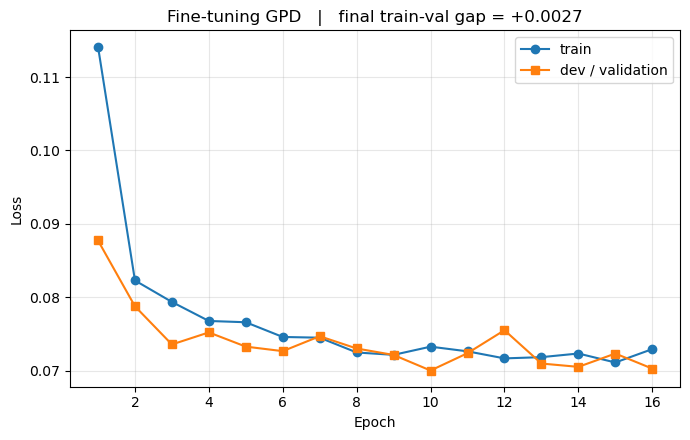

[OK] No sign of overfitting (best dev at epoch 10/16, final gap +0.0027).


In [7]:
tu.plot_loss(hist, ARCH)

## 7. Save fine-tuned weights

In [8]:
torch.save(model.state_dict(), FT_CKPT)
print("fine-tuned saved:", FT_CKPT)

fine-tuned saved: M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\processed\models\gpd_ft.pt
